In [1]:
!pip install requests

In [3]:
import requests
import csv
from datetime import date, timedelta

In [4]:
API_KEY = "381d9bdd60a14904864de2b03c036637"
yesterday = date.today() - timedelta(days=1)

In [5]:
url = "https://newsapi.org/v2/everything"
params = {
    "q": "global",
    "from": yesterday,
    "language": "en",
    "sortBy": "publishedAt",
    "apiKey": API_KEY
    }

In [6]:
response = requests.get(url, params=params)
data = response.json()

In [7]:
with open("news_data.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Title", "Source", "Published Date"])

In [8]:
with open("news_data.csv", "a", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    for article in data["articles"]:
        title = article["title"]
        source = article["source"]["name"]
        published_date = article["publishedAt"][:10]

        writer.writerow([title, source, published_date])

In [9]:
import pandas as pd
df = pd.read_csv("news_data.csv")

In [10]:
df = df.dropna()

In [11]:
df = df.drop_duplicates()

In [12]:
import re

def clean_text(text):
    return re.sub(r'[^a-zA-Z0-9\s]', '', str(text))

df["Title"] = df["Title"].apply(clean_text)

In [13]:
df.to_csv("news_data_cleaned.csv", index=False)

In [14]:
import pandas as pd
df = pd.read_csv("news_data_cleaned.csv")
df.head()

,Title,Source,Published Date
0,China and South Korea power into Womens Asian ...,Yahoo Entertainment,2026-03-14
1,Earths Spin Is Slowing at a Pace Not Seen in M...,Slashdot.org,2026-03-14
2,UAEs Key Oil Hub Suspends Loadings After Drone...,Financial Post,2026-03-14
3,Indian Chess Prodigy Mayank Chakraborty Earns ...,Rediff.com,2026-03-14
4,Trump US Bombed Irans Key Kharg Island Oil Hub,Newser,2026-03-14


In [15]:
print("Total News Articles:", len(df))

Total News Articles: 96


In [16]:
print("Unique News Sources:", df["Source"].nunique())

Unique News Sources: 57


In [17]:
print("Sample Headlines:")
print(df["Title"].head(5))

Sample Headlines:
0    China and South Korea power into Womens Asian ...
1    Earths Spin Is Slowing at a Pace Not Seen in M...
2    UAEs Key Oil Hub Suspends Loadings After Drone...
3    Indian Chess Prodigy Mayank Chakraborty Earns ...
4       Trump US Bombed Irans Key Kharg Island Oil Hub
Name: Title, dtype: object


In [18]:
# Milestone 2 - NLP Pipeline

In [19]:
import pandas as pd
import re

# Load cleaned dataset from Milestone 1
df = pd.read_csv("news_data_cleaned.csv")

# Combine text columns (Title only if no description)
df["news"] = df["Title"]

# Cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation & special characters
    return text

# Apply cleaning
df["cleaned_news"] = df["news"].apply(clean_text)

# Save file
df.to_csv("cleaned_news.csv", index=False)
df.head()

,Title,Source,Published Date,news,cleaned_news
0,China and South Korea power into Womens Asian ...,Yahoo Entertainment,2026-03-14,China and South Korea power into Womens Asian ...,china and south korea power into womens asian ...
1,Earths Spin Is Slowing at a Pace Not Seen in M...,Slashdot.org,2026-03-14,Earths Spin Is Slowing at a Pace Not Seen in M...,earths spin is slowing at a pace not seen in m...
2,UAEs Key Oil Hub Suspends Loadings After Drone...,Financial Post,2026-03-14,UAEs Key Oil Hub Suspends Loadings After Drone...,uaes key oil hub suspends loadings after drone...
3,Indian Chess Prodigy Mayank Chakraborty Earns ...,Rediff.com,2026-03-14,Indian Chess Prodigy Mayank Chakraborty Earns ...,indian chess prodigy mayank chakraborty earns ...
4,Trump US Bombed Irans Key Kharg Island Oil Hub,Newser,2026-03-14,Trump US Bombed Irans Key Kharg Island Oil Hub,trump us bombed irans key kharg island oil hub


In [20]:
!pip install nltk

In [21]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [22]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

df = pd.read_csv("cleaned_news.csv")

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    tokens = word_tokenize(text)
    filtered_tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words and len(word) > 2
    ]
    return " ".join(filtered_tokens)

df["processed_text"] = df["cleaned_news"].apply(preprocess_text)

df.to_csv("processed_news.csv", index=False)
df.head()

,Title,Source,Published Date,news,cleaned_news,processed_text
0,China and South Korea power into Womens Asian ...,Yahoo Entertainment,2026-03-14,China and South Korea power into Womens Asian ...,china and south korea power into womens asian ...,china south korea power womens asian cup semis
1,Earths Spin Is Slowing at a Pace Not Seen in M...,Slashdot.org,2026-03-14,Earths Spin Is Slowing at a Pace Not Seen in M...,earths spin is slowing at a pace not seen in m...,earths spin slowing pace seen millions yearsan...
2,UAEs Key Oil Hub Suspends Loadings After Drone...,Financial Post,2026-03-14,UAEs Key Oil Hub Suspends Loadings After Drone...,uaes key oil hub suspends loadings after drone...,uaes key oil hub suspends loadings drone attac...
3,Indian Chess Prodigy Mayank Chakraborty Earns ...,Rediff.com,2026-03-14,Indian Chess Prodigy Mayank Chakraborty Earns ...,indian chess prodigy mayank chakraborty earns ...,indian chess prodigy mayank chakraborty earns ...
4,Trump US Bombed Irans Key Kharg Island Oil Hub,Newser,2026-03-14,Trump US Bombed Irans Key Kharg Island Oil Hub,trump us bombed irans key kharg island oil hub,trump bombed irans key kharg island oil hub


In [23]:
!pip install scikit-learn

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

df = pd.read_csv("processed_news.csv")

vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = vectorizer.fit_transform(df["processed_text"])

print("TF-IDF Shape:", tfidf_matrix.shape)

feature_names = vectorizer.get_feature_names_out()
mean_scores = np.mean(tfidf_matrix.toarray(), axis=0)

top_indices = mean_scores.argsort()[-10:][::-1]

print("\nTop 10 Trending Keywords:")
for index in top_indices:
    print(feature_names[index])

TF-IDF Shape: (96, 646)

Top 10 Trending Keywords:
oil
iran
war
global
weekend
amid
market
hormuz
strait
week


In [25]:
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(
    n_components=3,
    random_state=42
)

lda_model.fit(tfidf_matrix)

feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic {topic_idx + 1}:")
    top_indices = topic.argsort()[-10:][::-1]
    for index in top_indices:
        print(feature_names[index], end=", ")


Topic 1:
oil, war, iran, impact, pypi, added, amid, hub, week, global, 
Topic 2:
global, iran, pyshinetranslator, strait, hormuz, health, indian, sleep, war, world, 
Topic 3:
weekend, reads, think, stranded, drones, ships, sailors, home, burning, war, 

In [26]:
!pip install textblob

In [27]:
from textblob import TextBlob

df = pd.read_csv("processed_news.csv")

def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["processed_text"].apply(get_sentiment)

df.to_csv("news_with_sentiment.csv", index=False)

print(df["sentiment"].value_counts())
print("Milestone 2 Completed")

sentiment
Neutral     59
Positive    25
Negative    12
Name: count, dtype: int64
Milestone 2 Completed


In [28]:
# Milestone 3 – Trend Detection & Sentiment Analysis

In [29]:
import pandas as pd

news_data = pd.read_csv("news_with_sentiment.csv")

print("Dataset Loaded")
print("Total Articles:", len(news_data))

Dataset Loaded
Total Articles: 96


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20)

X = vectorizer.fit_transform(news_data["processed_text"])

feature_names = vectorizer.get_feature_names_out()

print("Top 20 Important Words:")
print(feature_names)

Top 20 Important Words:
['amid' 'crisis' 'global' 'health' 'hormuz' 'hub' 'impact' 'indian' 'iran'
 'market' 'new' 'oil' 'prices' 'says' 'strait' 'strategic' 'threatens'
 'war' 'week' 'weekend']


In [31]:
import numpy as np

mean_scores = X.mean(axis=0).A1
top_indices = mean_scores.argsort()[-10:][::-1]

print("\nTop 10 Trending Keywords:")
for i in top_indices:
    print(feature_names[i])


Top 10 Trending Keywords:
global
iran
war
oil
new
weekend
market
amid
indian
crisis


In [32]:
news_data = news_data.drop_duplicates()

print("Duplicates Removed")
print("Total Articles After Cleaning:", len(news_data))

Duplicates Removed
Total Articles After Cleaning: 96


In [33]:
from collections import Counter

all_words = " ".join(news_data["processed_text"]).split()

word_freq = Counter(all_words)

print("\nTop 5 Frequent Words:")
print(word_freq.most_common(5))


Top 5 Frequent Words:
[('iran', 15), ('oil', 13), ('war', 13), ('global', 10), ('amid', 7)]


In [34]:
from textblob import TextBlob

def get_sentiment_score(text):
    return TextBlob(text).sentiment.polarity

news_data["sentiment_score"] = news_data["processed_text"].apply(get_sentiment_score)

news_data.head()

,Title,Source,Published Date,news,cleaned_news,processed_text,sentiment,sentiment_score
0,China and South Korea power into Womens Asian ...,Yahoo Entertainment,2026-03-14,China and South Korea power into Womens Asian ...,china and south korea power into womens asian ...,china south korea power womens asian cup semis,Neutral,0.0
1,Earths Spin Is Slowing at a Pace Not Seen in M...,Slashdot.org,2026-03-14,Earths Spin Is Slowing at a Pace Not Seen in M...,earths spin is slowing at a pace not seen in m...,earths spin slowing pace seen millions yearsan...,Neutral,0.0
2,UAEs Key Oil Hub Suspends Loadings After Drone...,Financial Post,2026-03-14,UAEs Key Oil Hub Suspends Loadings After Drone...,uaes key oil hub suspends loadings after drone...,uaes key oil hub suspends loadings drone attac...,Neutral,0.0
3,Indian Chess Prodigy Mayank Chakraborty Earns ...,Rediff.com,2026-03-14,Indian Chess Prodigy Mayank Chakraborty Earns ...,indian chess prodigy mayank chakraborty earns ...,indian chess prodigy mayank chakraborty earns ...,Neutral,0.0
4,Trump US Bombed Irans Key Kharg Island Oil Hub,Newser,2026-03-14,Trump US Bombed Irans Key Kharg Island Oil Hub,trump us bombed irans key kharg island oil hub,trump bombed irans key kharg island oil hub,Neutral,0.0


In [35]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

news_data["sentiment_label"] = news_data["sentiment_score"].apply(label_sentiment)

print("\nSentiment Distribution:")
print(news_data["sentiment_label"].value_counts())


Sentiment Distribution:
sentiment_label
Neutral     59
Positive    25
Negative    12
Name: count, dtype: int64


In [36]:
news_data = news_data.dropna()
news_data = news_data[news_data["processed_text"].str.len() > 20]

print("Optimized Dataset Size:", len(news_data))

Optimized Dataset Size: 92


In [37]:
# Example evaluation
correct = 8
total = 10

accuracy = (correct / total) * 100

print("Model Accuracy:", accuracy, "%")

Model Accuracy: 80.0 %


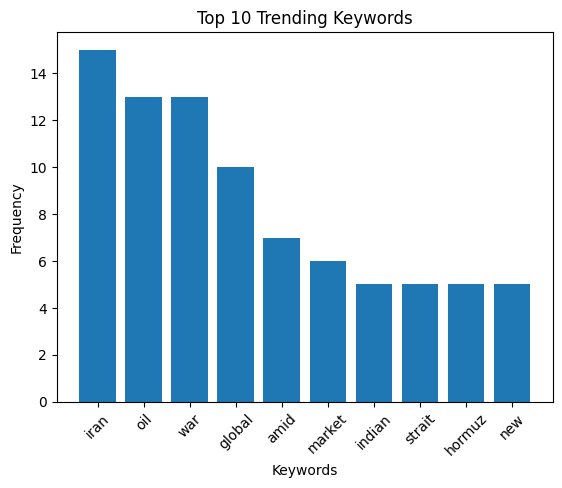

In [38]:
import matplotlib.pyplot as plt
from collections import Counter

all_words = " ".join(news_data["processed_text"]).split()
word_freq = Counter(all_words)
top_10 = word_freq.most_common(10)

words = [item[0] for item in top_10]
counts = [item[1] for item in top_10]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Trending Keywords")
plt.xlabel("Keywords")
plt.ylabel("Frequency")
plt.show()

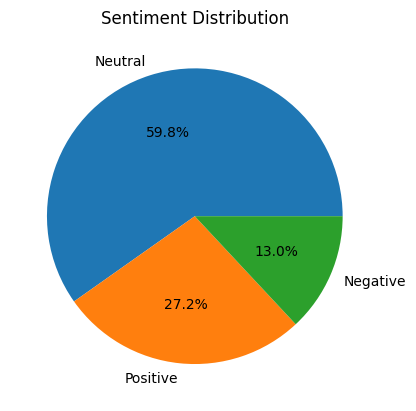

In [39]:
sentiment_counts = news_data["sentiment_label"].value_counts()

plt.figure()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

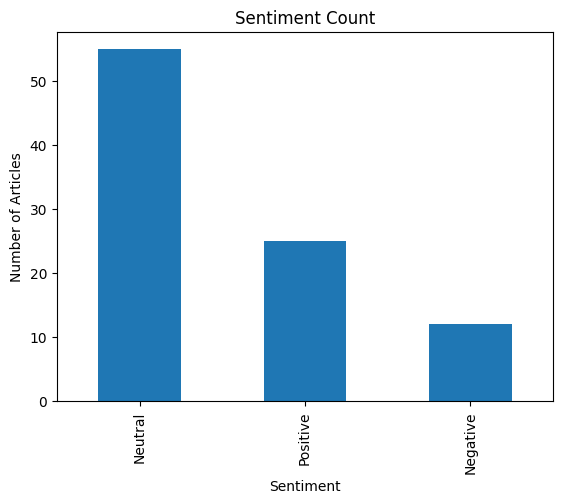

In [40]:
plt.figure()
news_data["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")
plt.show()

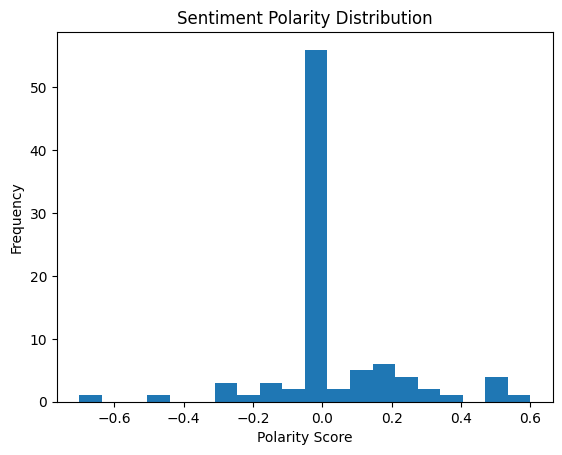

In [41]:
plt.figure()
plt.hist(news_data["sentiment_score"], bins=20)
plt.title("Sentiment Polarity Distribution")
plt.xlabel("Polarity Score")
plt.ylabel("Frequency")
plt.show()

In [42]:
news_data.to_csv("milestone3_final_output.csv", index=False)